<h1><center>Section 3 : Model Creation & Evaluation</center></h1>
<h2>Name: Yashvi Rabadiya</h2> 
<h2>Course: Machine Learning & Deep Learning</h2>
<h2>Dataset: Cardiovascular Disease Dataset (Kaggle)</h2>

### -> IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

### -> LOAD CLEANED DATASET

In [3]:
df = pd.read_csv('cardio_cleaned.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (68416, 16)

First 5 rows:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,map
0,18393,1,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,30,90.000000
1,20228,0,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,50,106.666667
2,18857,0,165,64.0,130,70,3,1,0,0,0,1,52,23.507805,60,90.000000
3,17623,1,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,50,116.666667
4,17474,0,156,56.0,100,60,1,1,0,0,0,0,48,23.011177,40,73.333333


In [4]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68416 entries, 0 to 68415
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             68416 non-null  int64  
 1   gender          68416 non-null  int64  
 2   height          68416 non-null  int64  
 3   weight          68416 non-null  float64
 4   ap_hi           68416 non-null  int64  
 5   ap_lo           68416 non-null  int64  
 6   cholesterol     68416 non-null  int64  
 7   gluc            68416 non-null  int64  
 8   smoke           68416 non-null  int64  
 9   alco            68416 non-null  int64  
 10  active          68416 non-null  int64  
 11  cardio          68416 non-null  int64  
 12  age_years       68416 non-null  int64  
 13  bmi             68416 non-null  float64
 14  pulse_pressure  68416 non-null  int64  
 15  map             68416 non-null  float64
dtypes: float64(3), int64(13)
memory usage: 8.4 MB


### -> PREPARE DATA FOR MODELING

In [6]:
# Select features for modeling
feature_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 
                'cholesterol', 'gluc', 'smoke', 'alco', 'active', 
                'bmi', 'pulse_pressure', 'map']

X = df[feature_cols]
y = df['cardio']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts())
print("\nTarget Percentage:")
print(y.value_counts(normalize=True) * 100)

Features Shape: (68416, 14)
Target Shape: (68416,)

Target Distribution:
cardio
0    34579
1    33837
Name: count, dtype: int64

Target Percentage:
cardio
0    50.542271
1    49.457729
Name: proportion, dtype: float64


In [7]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)
print("\nTraining Target Distribution:")
print(y_train.value_counts())
print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Set Size: (54732, 14)
Testing Set Size: (13684, 14)

Training Target Distribution:
cardio
0    27663
1    27069
Name: count, dtype: int64

Testing Target Distribution:
cardio
0    6916
1    6768
Name: count, dtype: int64


In [8]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("Training data scaled shape:", X_train_scaled.shape)
print("Testing data scaled shape:", X_test_scaled.shape)

Scaling completed successfully!
Training data scaled shape: (54732, 14)
Testing data scaled shape: (13684, 14)


### -> TRAIN MULTIPLE MODELS

In [10]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

print("Models initialized:")
for name in models.keys():
    print(f"- {name}")

Models initialized:
- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- Naive Bayes


In [14]:
# Train all models and store results
results = {}

print("Training Models...")
print("="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}")

print("\n" + "="*60)
print("All models trained successfully!")

Training Models...

Training Logistic Regression...
Logistic Regression - Accuracy: 0.7236

Training Decision Tree...
Decision Tree - Accuracy: 0.6329

Training Random Forest...
Random Forest - Accuracy: 0.7073

Training KNN...
KNN - Accuracy: 0.6991

Training Naive Bayes...
Naive Bayes - Accuracy: 0.7186

All models trained successfully!


### -> MODEL PERFORMANCE COMPARISON

In [20]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("Model Performance Comparison:")
print("="*60)
print(comparison_df.to_string(index=False))

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.723619   0.748585 0.664303  0.703930
        Naive Bayes  0.718576   0.769943 0.614657  0.683592
      Random Forest  0.707322   0.707713 0.695479  0.701543
                KNN  0.699138   0.700075 0.685284  0.692601
      Decision Tree  0.632929   0.627503 0.634456  0.630960


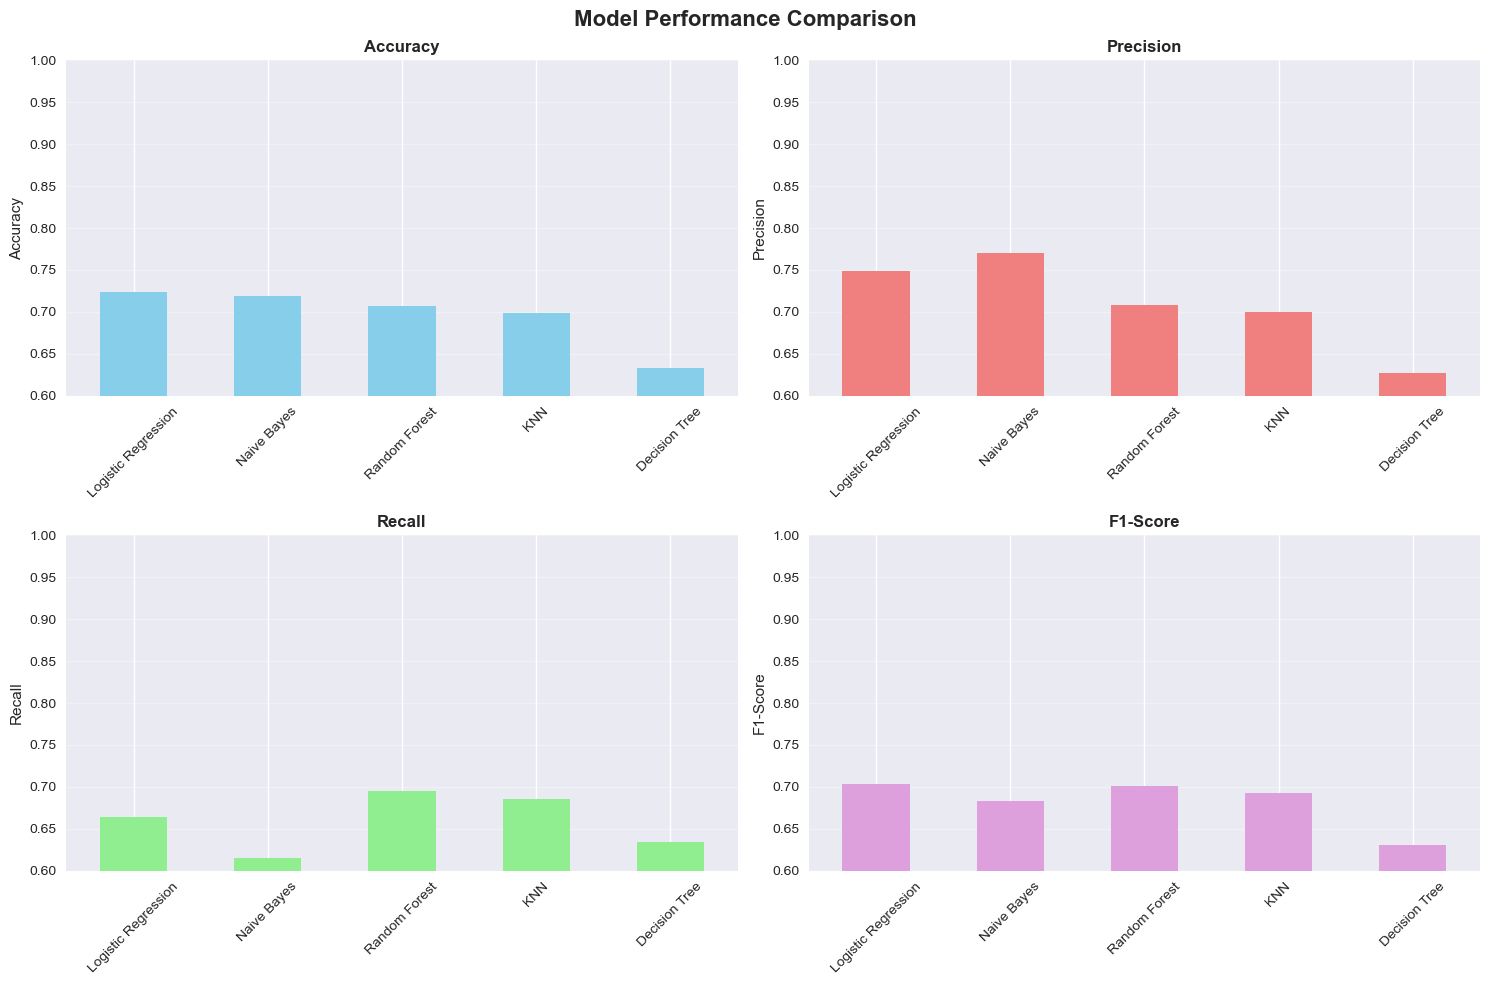

In [21]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'plum']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=axes[row, col], 
                       color=colors[idx], legend=False)
    axes[row, col].set_title(f'{metric}', fontweight='bold', fontsize=12)
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel(metric)
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3, axis='y')
    axes[row, col].set_ylim([0.6, 1.0])

plt.tight_layout()
plt.show()

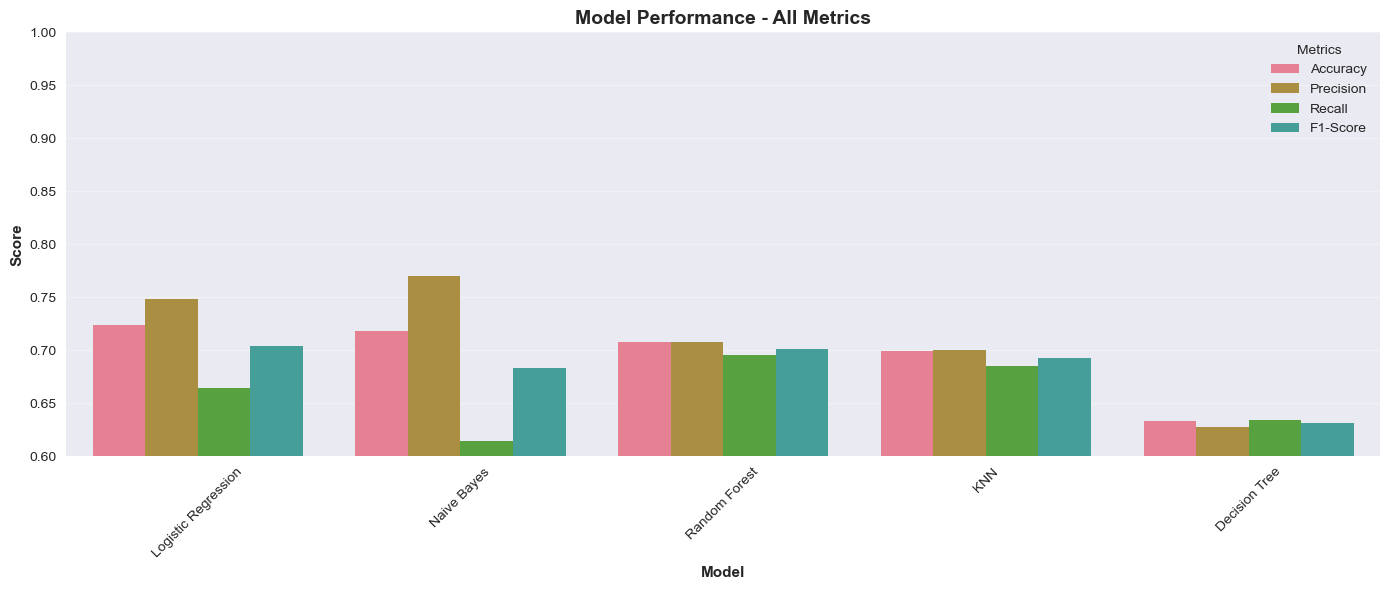

In [22]:
# Overall comparison plot
comparison_df_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=comparison_df_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance - All Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.ylim([0.6, 1.0])
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### -> CONFUSION MATRIX FOR ALL MODELS

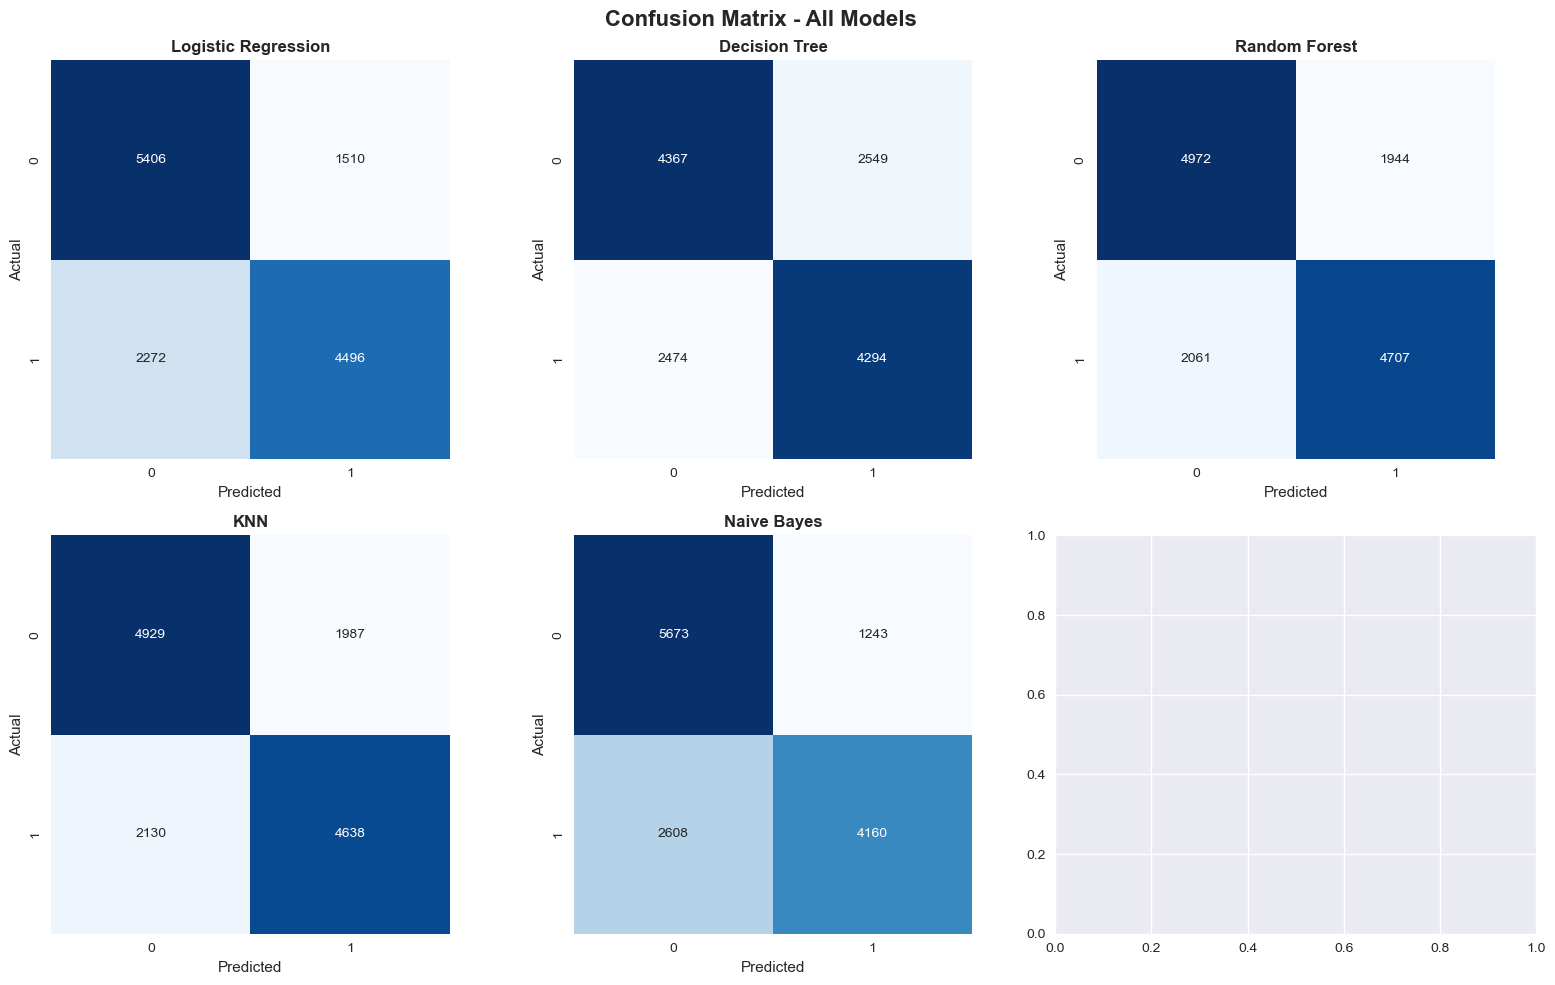

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrix - All Models', fontsize=16, fontweight='bold')

for idx, (name, result) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                cbar=False, square=True)
    axes[row, col].set_title(f'{name}', fontweight='bold')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### -> DETAILED CLASSIFICATION REPORT

In [26]:
# Get best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_result = results[best_model_name]

print(f"BEST MODEL: {best_model_name}")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, best_model_result['y_pred'], 
                          target_names=['No Disease', 'Disease']))

BEST MODEL: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.70      0.78      0.74      6916
     Disease       0.75      0.66      0.70      6768

    accuracy                           0.72     13684
   macro avg       0.73      0.72      0.72     13684
weighted avg       0.73      0.72      0.72     13684



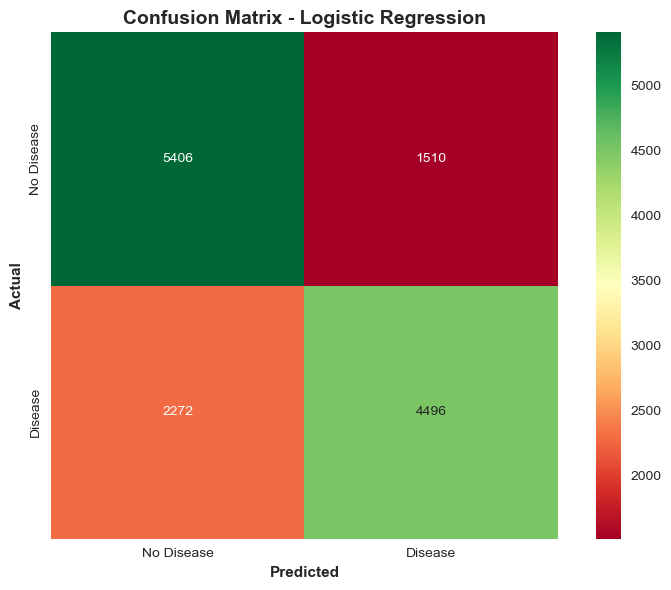


True Negatives: 5406
False Positives: 1510
False Negatives: 2272
True Positives: 4496


In [27]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_model_result['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', square=True, 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

### -> ROC CURVE AND AUC SCORE

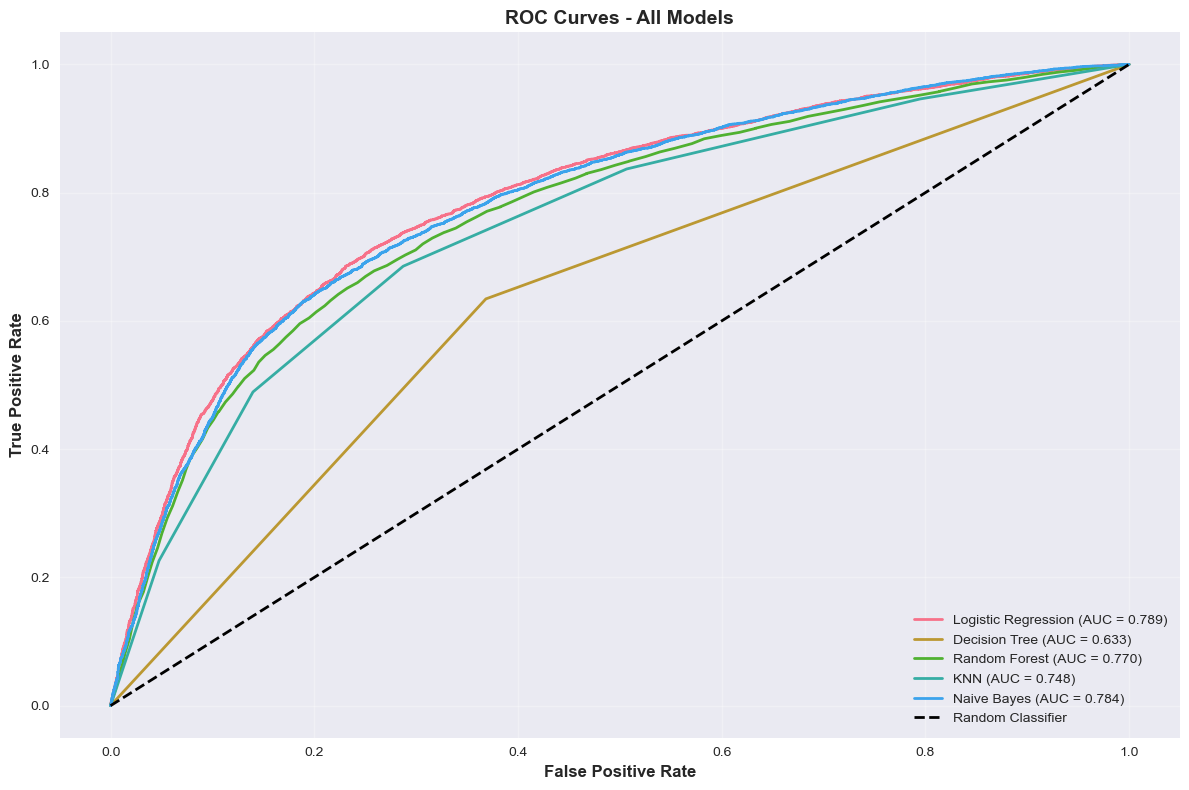

In [29]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name, result in results.items():
    model = result['model']
    
    # Get probability predictions
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test_scaled)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Calculate AUC scores for all models
auc_scores = {}

for name, result in results.items():
    model = result['model']
    
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test_scaled)
    
    auc_score = roc_auc_score(y_test, y_pred_proba)
    auc_scores[name] = auc_score

print("AUC Scores:")
print("="*60)
for name, score in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:25s}: {score:.4f}")

AUC Scores:
Logistic Regression      : 0.7892
Naive Bayes              : 0.7840
Random Forest            : 0.7700
KNN                      : 0.7485
Decision Tree            : 0.6329


### -> CHECK OVERFITTING/UNDERFITTING

In [32]:
# Check train vs test performance
print("Training vs Testing Performance:")
print("="*60)

for name, result in results.items():
    model = result['model']
    
    # Training accuracy
    y_train_pred = model.predict(X_train_scaled)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    
    # Testing accuracy
    test_accuracy = result['accuracy']
    
    # Difference
    diff = train_accuracy - test_accuracy
    
    print(f"\n{name}:")
    print(f"  Training Accuracy:  {train_accuracy:.4f}")
    print(f"  Testing Accuracy:   {test_accuracy:.4f}")
    print(f"  Difference:         {diff:.4f}")
    
    if diff > 0.05:
        print(f"  Status: ⚠️ Overfitting detected!")
    elif test_accuracy < 0.65:
        print(f"  Status: ⚠️ Underfitting detected!")
    else:
        print(f"  Status: ✅ Good fit!")

Training vs Testing Performance:

Logistic Regression:
  Training Accuracy:  0.7280
  Testing Accuracy:   0.7236
  Difference:         0.0044
  Status: ✅ Good fit!

Decision Tree:
  Training Accuracy:  0.9998
  Testing Accuracy:   0.6329
  Difference:         0.3669
  Status: ⚠️ Overfitting detected!

Random Forest:
  Training Accuracy:  0.9998
  Testing Accuracy:   0.7073
  Difference:         0.2924
  Status: ⚠️ Overfitting detected!

KNN:
  Training Accuracy:  0.7835
  Testing Accuracy:   0.6991
  Difference:         0.0843
  Status: ⚠️ Overfitting detected!

Naive Bayes:
  Training Accuracy:  0.7220
  Testing Accuracy:   0.7186
  Difference:         0.0034
  Status: ✅ Good fit!


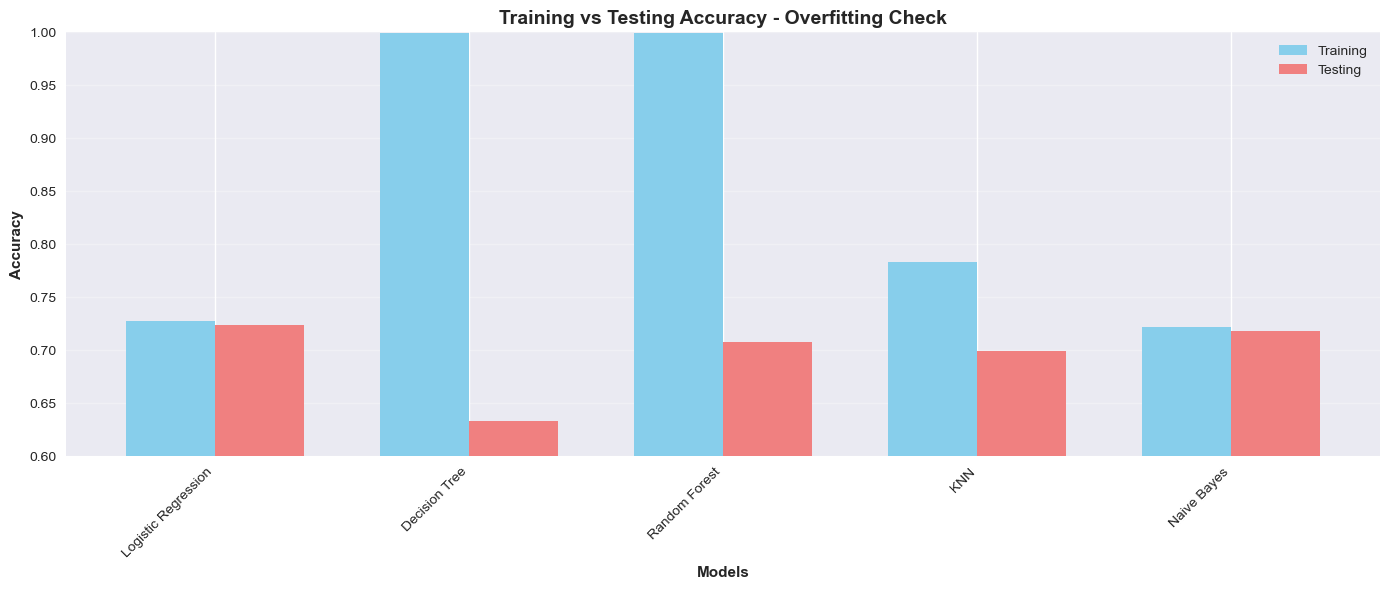

In [33]:
# Visualize overfitting/underfitting
train_scores = []
test_scores = []
model_names = []

for name, result in results.items():
    model = result['model']
    y_train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = result['accuracy']
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    model_names.append(name)

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_scores, width, label='Training', color='skyblue')
bars2 = ax.bar(x + width/2, test_scores, width, label='Testing', color='lightcoral')

ax.set_xlabel('Models', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Training vs Testing Accuracy - Overfitting Check', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.6, 1.0])

plt.tight_layout()
plt.show()

### -> CROSS-VALIDATION

In [35]:
# Perform cross-validation
cv_results = {}

print("Cross-Validation Results (5-Fold):")
print("="*60)

for name, result in results.items():
    model = result['model']
    
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    cv_results[name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean:      {cv_scores.mean():.4f}")
    print(f"  Std Dev:   {cv_scores.std():.4f}")

Cross-Validation Results (5-Fold):

Logistic Regression:
  CV Scores: [0.72266374 0.72421668 0.73131738 0.73469761 0.72821122]
  Mean:      0.7282
  Std Dev:   0.0044

Decision Tree:
  CV Scores: [0.63652142 0.63560793 0.63877215 0.63411292 0.63338206]
  Mean:      0.6357
  Std Dev:   0.0019

Random Forest:
  CV Scores: [0.70603818 0.70503334 0.70820391 0.71907546 0.71094464]
  Mean:      0.7099
  Std Dev:   0.0050

KNN:
  CV Scores: [0.69105691 0.68795104 0.69852001 0.70180888 0.69833729]
  Mean:      0.6955
  Std Dev:   0.0052

Naive Bayes:
  CV Scores: [0.71763954 0.71983192 0.72300384 0.72528778 0.72291248]
  Mean:      0.7217
  Std Dev:   0.0027


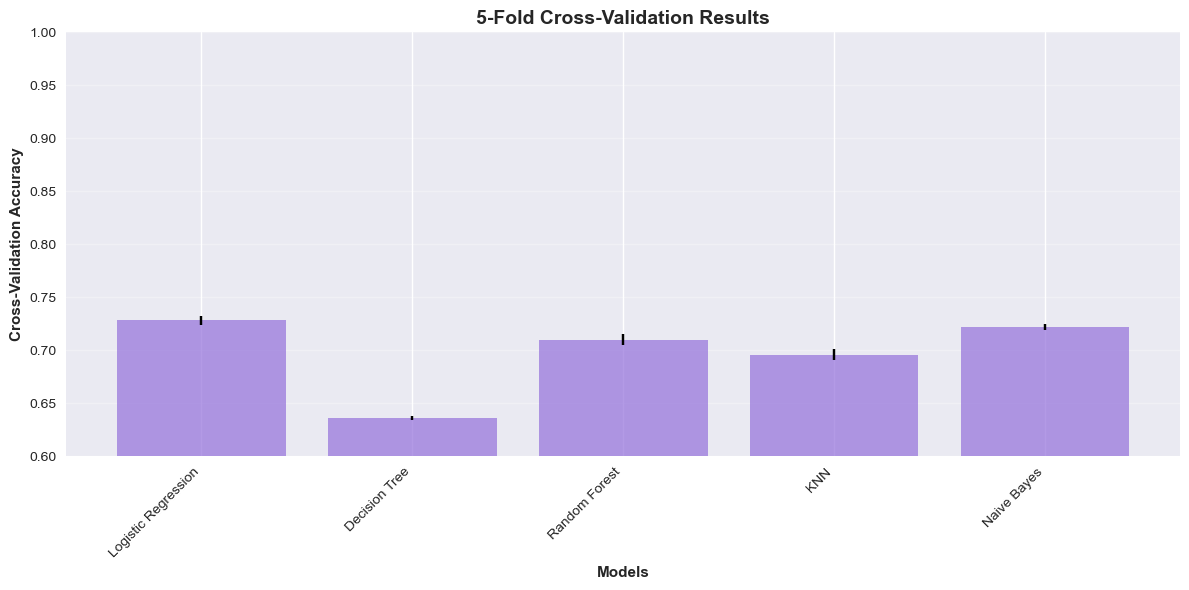

In [36]:
# Visualize cross-validation results
cv_means = [cv_results[name]['mean'] for name in model_names]
cv_stds = [cv_results[name]['std'] for name in model_names]

plt.figure(figsize=(12, 6))
plt.bar(model_names, cv_means, yerr=cv_stds, capsize=5, color='mediumpurple', alpha=0.7)
plt.xlabel('Models', fontweight='bold')
plt.ylabel('Cross-Validation Accuracy', fontweight='bold')
plt.title('5-Fold Cross-Validation Results', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim([0.6, 1.0])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### -> HYPERPARAMETER TUNING (Best Model)

In [38]:
# Hyperparameter tuning for best model
print(f"Hyperparameter Tuning for: {best_model_name}")
print("="*60)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42)
    
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }
    base_model = LogisticRegression(random_state=42, max_iter=1000)
    
elif best_model_name == 'Decision Tree':
    param_grid = {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }
    base_model = DecisionTreeClassifier(random_state=42)
    
else:
    param_grid = {'C': [0.1, 1, 10]}
    base_model = results[best_model_name]['model']

print("Parameter grid:", param_grid)

Hyperparameter Tuning for: Logistic Regression
Parameter grid: {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}


In [39]:
# Grid Search
grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.7283309407780434


In [40]:
# Evaluate tuned model
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("\nTuned Model Performance:")
print("="*60)
print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")

print("\nComparison with Base Model:")
print(f"Base Accuracy:  {results[best_model_name]['accuracy']:.4f}")
print(f"Tuned Accuracy: {tuned_accuracy:.4f}")
print(f"Improvement:    {tuned_accuracy - results[best_model_name]['accuracy']:.4f}")


Tuned Model Performance:
Accuracy:  0.7237
Precision: 0.7488
Recall:    0.6642
F1-Score:  0.7039

Comparison with Base Model:
Base Accuracy:  0.7236
Tuned Accuracy: 0.7237
Improvement:    0.0001


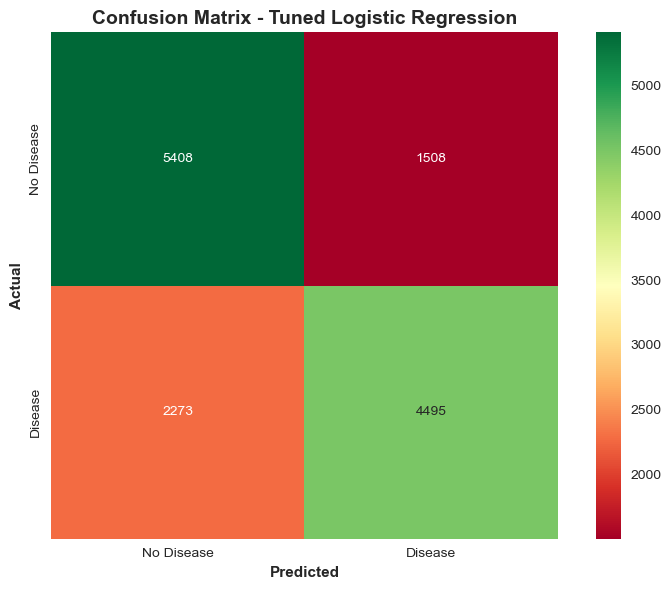

In [41]:
# Confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='RdYlGn', square=True,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - Tuned {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.tight_layout()
plt.show()

### -> FEATURE IMPORTANCE (If Applicable)

In [43]:
# Feature importance for tree-based models
if hasattr(best_tuned_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_tuned_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Feature Importance:")
    print("="*60)
    print(feature_importance.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
    plt.xlabel('Importance', fontweight='bold')
    plt.ylabel('Features', fontweight='bold')
    plt.title(f'Feature Importance - {best_model_name}', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance not available for {best_model_name}")

Feature importance not available for Logistic Regression


### -> SAVE BEST MODEL

In [45]:
import pickle

# Save the best tuned model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Best model saved as: best_model.pkl")
print("✅ Scaler saved as: scaler.pkl")

✅ Best model saved as: best_model.pkl
✅ Scaler saved as: scaler.pkl


### -> MODEL EVALUATION SUMMARY

In [47]:
print("="*60)
print("MODEL EVALUATION SUMMARY")
print("="*60)

print(f"\n1. Total Models Trained: {len(models)}")
print(f"\n2. Best Model: {best_model_name}")
print(f"   - Accuracy:  {tuned_accuracy:.4f}")
print(f"   - Precision: {tuned_precision:.4f}")
print(f"   - Recall:    {tuned_recall:.4f}")
print(f"   - F1-Score:  {tuned_f1:.4f}")

print(f"\n3. Hyperparameter Tuning:")
print(f"   - Method: Grid Search with 5-Fold CV")
print(f"   - Best Parameters: {grid_search.best_params_}")

print(f"\n4. Model Status:")
train_acc = accuracy_score(y_train, best_tuned_model.predict(X_train_scaled))
diff = train_acc - tuned_accuracy
if diff > 0.05:
    print(f"   ⚠️ Slight overfitting detected (diff: {diff:.4f})")
else:
    print(f"   ✅ Good generalization (diff: {diff:.4f})")

print(f"\n5. Files Saved:")
print(f"   - best_model.pkl")
print(f"   - scaler.pkl")

print("\n" + "="*60)
print("Ready for Section 4: Visualization & Flask Setup")
print("="*60)

MODEL EVALUATION SUMMARY

1. Total Models Trained: 5

2. Best Model: Logistic Regression
   - Accuracy:  0.7237
   - Precision: 0.7488
   - Recall:    0.6642
   - F1-Score:  0.7039

3. Hyperparameter Tuning:
   - Method: Grid Search with 5-Fold CV
   - Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}

4. Model Status:
   ✅ Good generalization (diff: 0.0043)

5. Files Saved:
   - best_model.pkl
   - scaler.pkl

Ready for Section 4: Visualization & Flask Setup
